# Exploratory Data Analysis (EDA)

In [1]:
# Automatically reloads modules when you make changes (useful during development)
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))

from src.data import load_data
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl = load_data()

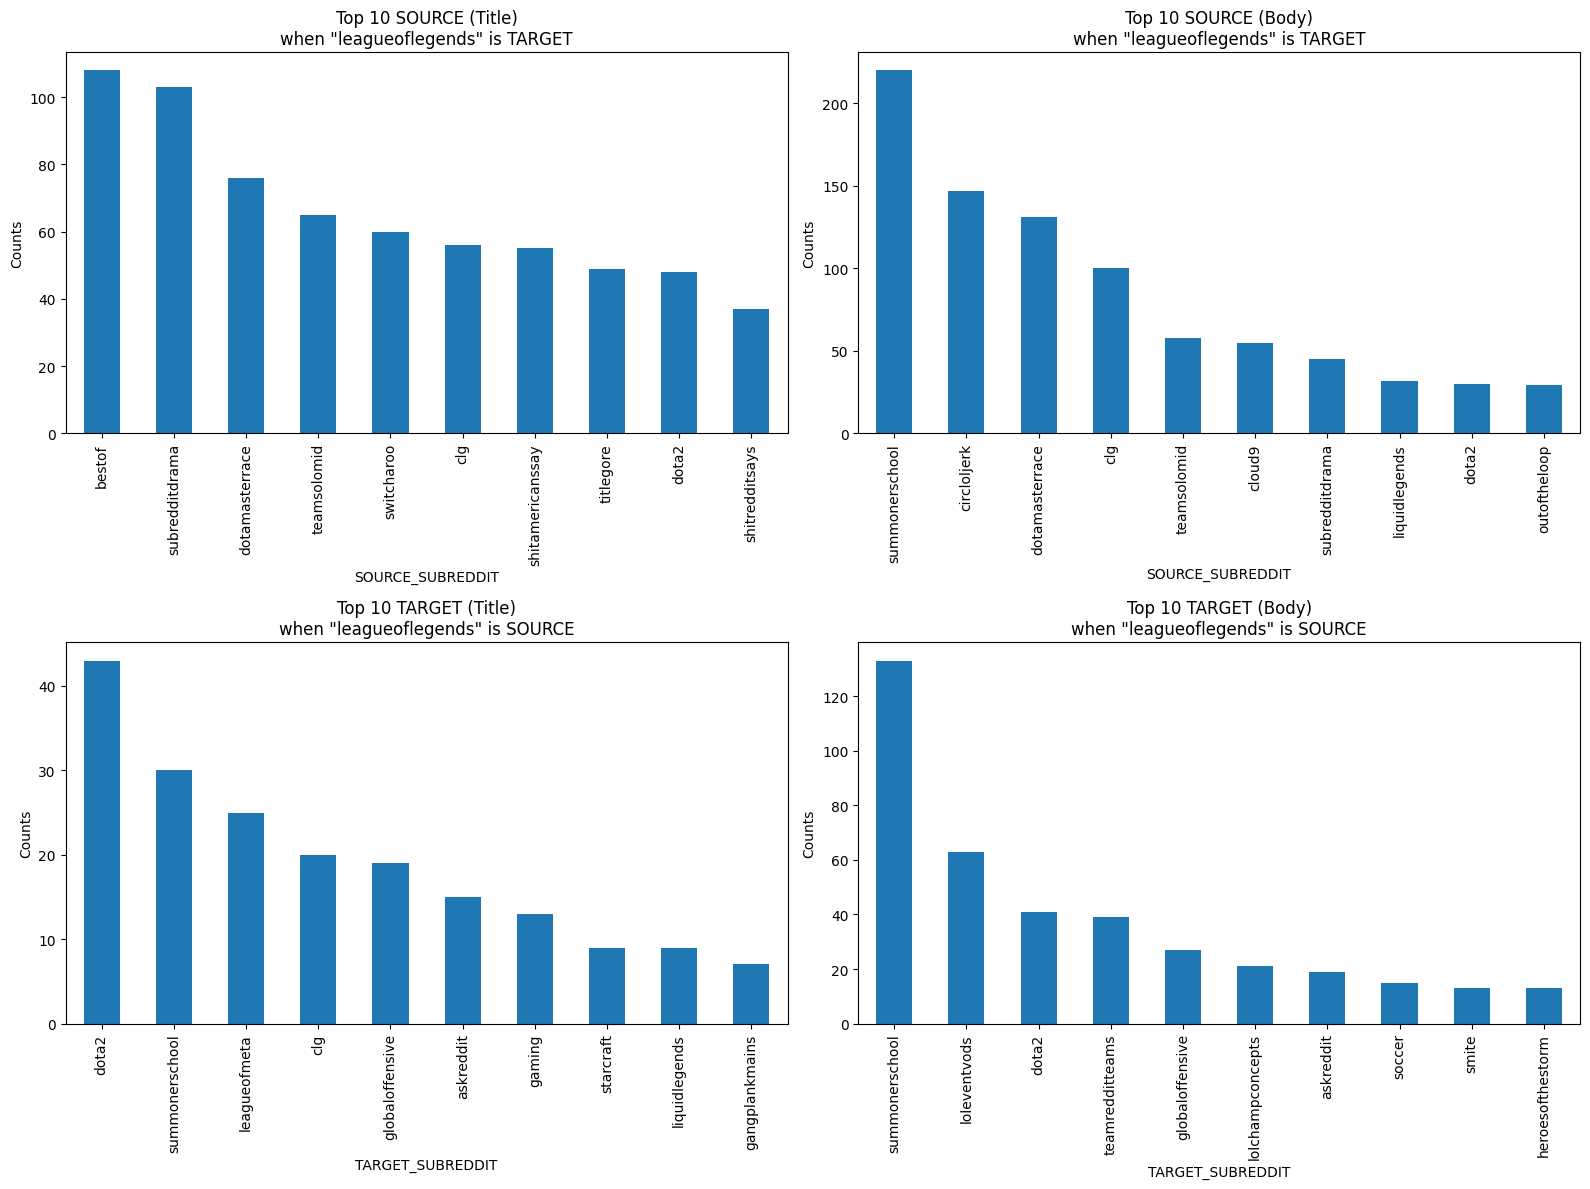

In [3]:
# subreddit = 'dota2'
subreddit = "leagueoflegends"
# subreddit = 'starcraft2'
# subreddit = 'globaloffensive' # globaloffensive or csgo

top_10_source_title = df_title[df_title["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_title = df_title[df_title["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

top_10_source_body = df_body[df_body["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_body = df_body[df_body["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

plt.figure(figsize=(16, 12))

# 1. Source Title
plt.subplot(2, 2, 1)
top_10_source_title.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Title)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 2. Source Body
plt.subplot(2, 2, 2)
top_10_source_body.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Body)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 3. Target Title
plt.subplot(2, 2, 3)
top_10_target_title.plot(kind='bar')
plt.title(f'Top 10 TARGET (Title)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

# 4. Target Body
plt.subplot(2, 2, 4)
top_10_target_body.plot(kind='bar')
plt.title(f'Top 10 TARGET (Body)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()


In [4]:
dota2_list = []
string = "dota2"
temp = list(df_body[df_body["SOURCE_SUBREDDIT"].str.contains("dota2", case=False, na=False)].SOURCE_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_body[df_body["TARGET_SUBREDDIT"].str.contains("dota2", case=False, na=False)].TARGET_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_title[df_title["SOURCE_SUBREDDIT"].str.contains("dota2", case=False, na=False)].SOURCE_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_title[df_title["TARGET_SUBREDDIT"].str.contains("dota2", case=False, na=False)].TARGET_SUBREDDIT.unique())
dota2_list.extend(temp)
dota2_list = list(set(dota2_list))
print(f"Total unique subreddits related to 'dota2': {len(dota2_list)}")
# smite_list

Total unique subreddits related to 'dota2': 74


In [5]:
df = df_title
sub = df[df["SOURCE_SUBREDDIT"].isin(dota2_list) | df["TARGET_SUBREDDIT"].isin(dota2_list)]
print(sub["SOURCE_SUBREDDIT"].value_counts().head(10))
print(sub["TARGET_SUBREDDIT"].value_counts().head(10))

SOURCE_SUBREDDIT
dota2              653
dota2circlejerk    195
subredditdrama      91
dotamasterrace      79
bestof              75
learndota2          61
shitredditsays      48
leagueoflegends     45
titlegore           34
circlebroke2        33
Name: count, dtype: int64
TARGET_SUBREDDIT
dota2              1480
leagueoflegends      52
globaloffensive      44
learndota2           36
dota2modding         30
askreddit            29
dotaconcepts         28
truedota2            27
steam                23
dota2circlejerk      18
Name: count, dtype: int64


In [6]:
temp_list = []
string = "smite"
temp = list(df_body[df_body["SOURCE_SUBREDDIT"].str.contains(string, case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_body[df_body["TARGET_SUBREDDIT"].str.contains(string, case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_title[df_title["SOURCE_SUBREDDIT"].str.contains(string, case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_title[df_title["TARGET_SUBREDDIT"].str.contains(string, case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)
temp_list = list(set(temp_list))
print(f"Total unique subreddits related to {string}: {len(temp_list)}")

Total unique subreddits related to smite: 34


In [7]:
temp_list


['smite_irl',
 'collegesmite',
 'smitedadjokes',
 'xboxsmite',
 'smiteccl',
 'smitepro',
 'smiteoceanic',
 'smiteps4',
 'smiteart',
 'lytesmites',
 'smitetraining',
 'smitejokes',
 'smitexenia',
 'competitive_smite',
 'smitehotplays',
 'smiteinfobot',
 'smiteeventvods',
 'smiteskinconcepts',
 'smitelfm',
 'smitelft',
 'smiteuncensored',
 'smiterants',
 'smitecirclejerk',
 'smiteodyssey',
 'smitetactics',
 'smite_jp',
 'smiteserious',
 'smitejoust',
 'smitevod',
 'smiteduel',
 'smite',
 'pocketsmite',
 'smitegodconcepts',
 'smitetrades']

In [8]:
dota2_subreddits = [
    'dota2', 'dota2circlejerk','dota2trade', 'learndota2', 'dota2betting', 
    'dotamasterrace', 'truedota2', 'dota2modding', 'dota2loungebets', 'redditdota2league',
]
lol_subreddits = [
    "leagueoflegends", "leagueoflegendsmeta", "summonerschool",  "clg", 
    "circloljerk", 'leagueconnect', 'lolesports'
    ]

# starcraft2_subreddits = [
#      'starcraft2',  'starcraft', 'starcraftcirclejerk', 'unexpectedstarcraft',
#      'imaginarystarcraft', 'starcraft_strategy', 'ukstarcraft', 'starcraftbirthdays',
#      'starcraftdeutschland', 'huskystarcraft', 'starcraftfeedback','psystarcraft',]

globaloffensive_subreddits = [
    'globaloffensive', 'globaloffensivetrade', 'globaloffensivemarket',
    'csgo', 'csgojerk', 'csgobetting',
]

games = ["gaming", "dota2", "leagueoflegends", "globaloffensive"]


In [43]:
from datetime import datetime

dates_list = list(df_esports.query(f"TournamentName in {dota_tournament}")[["StartDate", "EndDate"]].itertuples(index=False, name=None))
print(dates_list)
formatted=[(datetime.strptime(s,"%m/%d/%y").strftime("%Y-%m-%d"),
            datetime.strptime(e,"%m/%d/%y").strftime("%Y-%m-%d"))
           for s,e in dates_list]
formatted

[('7/8/14', '7/21/14'), ('1/5/15', '2/9/15'), ('8/3/15', '8/8/15'), ('11/16/15', '11/21/15'), ('12/17/15', '12/20/15'), ('3/2/16', '3/6/16'), ('6/3/16', '6/12/16'), ('8/3/16', '8/13/16'), ('9/2/16', '12/31/16'), ('12/3/16', '12/10/16'), ('12/14/16', '12/16/16'), ('1/12/17', '1/15/17'), ('3/27/17', '4/4/17'), ('4/24/17', '4/30/17')]


[('2014-07-08', '2014-07-21'),
 ('2015-01-05', '2015-02-09'),
 ('2015-08-03', '2015-08-08'),
 ('2015-11-16', '2015-11-21'),
 ('2015-12-17', '2015-12-20'),
 ('2016-03-02', '2016-03-06'),
 ('2016-06-03', '2016-06-12'),
 ('2016-08-03', '2016-08-13'),
 ('2016-09-02', '2016-12-31'),
 ('2016-12-03', '2016-12-10'),
 ('2016-12-14', '2016-12-16'),
 ('2017-01-12', '2017-01-15'),
 ('2017-03-27', '2017-04-04'),
 ('2017-04-24', '2017-04-30')]

In [34]:
df_esports

,GameID,TournamentName,StartDate,EndDate,City,Country,TeamPlay,TotalUSDPrize,year
0,5079.0,Call of Duty Championship 2014,3/28/14,3/30/14,Los Angeles,United States,1.0,1000000.00,14.0
1,6418.0,The International 2014,7/8/14,7/21/14,Seattle/Washington,United States,1.0,10931103.00,14.0
2,7376.0,LoL 2014 World Championship,9/18/14,10/19/14,Taipei/Singapore,Taiwan/Singapore,1.0,2130000.00,14.0
3,9205.0,DAC 2015,1/5/15,2/9/15,Shangai,China,1.0,3057521.00,15.0
4,8885.0,Smite World Championship 2015,1/9/15,1/1/15,Atlanta,United States,1.0,2612259.00,15.0
5,9797.0,Call of Duty Championship 2015,3/27/15,3/29/15,Los Angeles,United States,1.0,1000000.00,15.0
6,12894.0,The International 2015,8/3/15,8/8/15,Seattle/Washington,United States,1.0,18429613.05,15.0
7,15149.0,LoL 2015 World Championship,10/1/15,10/31/15,Paris,France,1.0,2130000.00,15.0
8,15444.0,The Frankfurt Major 2015,11/16/15,11/21/15,Frankfurt,Germany,1.0,3000000.00,15.0
9,15987.0,World Cyber Arena 2015 (Dota 2),12/17/15,12/20/15,Yinchuan,China,1.0,677284.40,15.0


In [30]:
dota_tournament = [
    "The International 2014",
    "DAC 2015",
    "The International 2015",
    "The Frankfurt Major 2015",
    "World Cyber Arena 2015 (Dota 2)",
    "The Shanghai Major 2016",
    "The Manila Major 2016",
    "The International 2016",
    "Dota2 Professional League Season 2 - Top",
    "The Boston Major 2016",
    "World Cyber Arena 2016 (Dota 2)",
    "WESG 2016 (Dota 2)",
    "DAC 2017",
    "The Kiev Major 2017"
]

lol_tournament = [
    "LoL 2014 World Championship",
    "LoL 2015 World Championship",
    "LPL Spring 2016",
    "LPL Summer 2016",
    "LoL 2016 World Championship"
]

csgo_tournament = [
    "MLG Major Championship: Columbus 2016",
    "ESL Pro League S3 Finals",
    "ELEAGUE Season 1",
    "Esports Championship Series Season 1 - Finals",
    "ESL One: Cologne 2016",
    "ELEAGUE Season 2",
    "ESL Pro League Season 4: Finals",
    "Esports Championship Series Season 2 - Finals",
    "WESG 2016 (CS:GO)",
    "ELEAGUE Major 2017"
]

In [31]:
selected_PROPERTIES = {
    "LIWC_SOC": "LIWC Social", # Social process words (talk, friend, share)
    "LIWC_FAM": "LIWC Family", # Family-related words
    "LIWC_FRIEND": "LIWC Friends", # Friends / peer-related words
    "LIWC_HUMAN": "LIWC Humans", # References to people / humans
    "LIWC_ACHIEV": "LIWC Achievement", # Achievement / goal words
    "LIWC_LEISURE": "LIWC Leisure", # Leisure and recreation words
    "LIWC_HOME": "LIWC Home", # Home / domestic words
    "LIWC_MONEY": "LIWC Money", # Money / finance words
    "LIWC_WORK": "LIWC Work", # Work and occupational words
    "LIWC_AFFECT": "LIWC Affect", # Emotion words
    "LIWC_POSEMO": "LIWC Pos. emotion", # Positive emotion words
    "LIWC_NEGEMO": "LIWC Neg. emotion", # Negative emotion words
    "LIWC_ANX": "LIWC Anxiety", # Anxiety-related words (nervous, afraid)
    "LIWC_ANGER": "LIWC Anger", # Anger-related words
    "LIWC_SAD": "LIWC Sadness", # Sadness-related words
    "LIWC_MOTION": "LIWC Motion", # Motion verbs (go, move, travel)
    "LIWC_SPACE": "LIWC Space", # Spatial / location words (left, above)
    "LIWC_PERCEPT": "LIWC Perceptual", # Perceptual processes (see, hear, feel)
    "LIWC_SEE": "LIWC See", # Vision-related words
    "LIWC_HEAR": "LIWC Hear", # Hearing-related words
    "LIWC_FEEL": "LIWC Feel", # Sensation / feeling words
}

In [32]:
# selected_PROPERTIES = {
#     "LIWC_NEG": "LIWC Negation", # Negations (not, no, never)
#     "LIWC_QUANT": "LIWC Quantifiers", # Quantifiers (many, few, much)
#     "LIWC_NUM": "LIWC Numbers", # Numerals and number words
#     "LIWC_SWEAR": "LIWC Swear", # Profanity / swear words
#     "LIWC_SOC": "LIWC Social", # Social process words (talk, friend, share)
#     "LIWC_FAM": "LIWC Family", # Family-related words
#     "LIWC_FRIEND": "LIWC Friends", # Friends / peer-related words
#     "LIWC_HUMAN": "LIWC Humans", # References to people / humans
#     "LIWC_AFFECT": "LIWC Affect", # Emotion words
#     "LIWC_POSEMO": "LIWC Pos. emotion", # Positive emotion words
#     "LIWC_NEGEMO": "LIWC Neg. emotion", # Negative emotion words
#     "LIWC_ANX": "LIWC Anxiety", # Anxiety-related words (nervous, afraid)
#     "LIWC_ANGER": "LIWC Anger", # Anger-related words
#     "LIWC_SAD": "LIWC Sadness", # Sadness-related words
#     "LIWC_INSIGHT": "LIWC Insight", # Insight words (realize, understand)
#     "LIWC_CERT": "LIWC Certainty", # Certainty words (definitely, sure)
#     "LIWC_INHIB": "LIWC Inhibition", # Inhibition words (stop, prevent, avoid)
#     "LIWC_PERCEPT": "LIWC Perceptual", # Perceptual processes (see, hear, feel)
#     "LIWC_SEE": "LIWC See", # Vision-related words
#     "LIWC_HEAR": "LIWC Hear", # Hearing-related words
#     "LIWC_FEEL": "LIWC Feel", # Sensation / feeling words
#     "LIWC_BIO": "LIWC Biological", # Biological process words (eat, sleep)
#     "LIWC_BODY": "LIWC Body", # Body-part words (arm, head)
#     "LIWC_HEALTH": "LIWC Health", # Health-related words
#     "LIWC_SEX": "LIWC Sexual", # Sexual content words
#     "LIWC_INGEST": "LIWC Ingest", # Eating / drinking words (eat, drink)
#     # "LIWC_RELAT": "LIWC Relativity", # Relativity / relational words (near, far)
#     "LIWC_MOTION": "LIWC Motion", # Motion verbs (go, move, travel)
#     "LIWC_SPACE": "LIWC Space", # Spatial / location words (left, above)
#     "LIWC_TIME": "LIWC Time", # Temporal words (when, day, year)
#     "LIWC_WORK": "LIWC Work", # Work and occupational words
#     "LIWC_ACHIEV": "LIWC Achievement", # Achievement / goal words
#     "LIWC_LEISURE": "LIWC Leisure", # Leisure and recreation words
#     "LIWC_HOME": "LIWC Home", # Home / domestic words
#     "LIWC_MONEY": "LIWC Money", # Money / finance words
#     "LIWC_RELIG": "LIWC Religion", # Religion and spirituality words
#     "LIWC_DEATH": "LIWC Death", # Death-related words
#     "LIWC_ASSENT": "LIWC Assent", # Agreement / approval words (yes, okay)
#     "LIWC_DISSENT": "LIWC Dissent", # Disagreement / opposition words (no, oppose)
# }

### Sentiment andLIWC attributes

Length of selected properties: 21


,Feature,Mean_Title,Max_Title,Sum_Title,Std_Title,Mean_Body,Max_Body,Sum_Body,Std_Body
0,LIWC_SOC,0.05832,0.67,742.84,0.07389,0.07403,0.32,565.66,0.03530
9,LIWC_AFFECT,0.04500,0.75,573.17,0.06376,0.04141,0.21,316.43,0.02909
8,LIWC_WORK,0.01425,0.43,181.56,0.03618,0.04031,0.33,308.00,0.02564
16,LIWC_SPACE,0.04307,0.40,548.57,0.05887,0.03912,0.25,298.95,0.02743
10,LIWC_POSEMO,0.02835,0.40,361.05,0.05040,0.02952,0.14,225.59,0.02403
5,LIWC_LEISURE,0.03446,0.50,438.89,0.05611,0.02071,0.17,158.22,0.02225
4,LIWC_ACHIEV,0.01597,0.33,203.45,0.03801,0.01673,0.16,127.83,0.01851
17,LIWC_PERCEPT,0.01134,0.60,144.42,0.03204,0.01302,0.11,99.48,0.01507
11,LIWC_NEGEMO,0.01663,0.75,211.80,0.04153,0.01176,0.14,89.89,0.01527
15,LIWC_MOTION,0.01105,0.40,140.77,0.03068,0.00980,0.12,74.88,0.01197


['LIWC_SOC', 'LIWC_AFFECT', 'LIWC_SPACE', 'LIWC_LEISURE', 'LIWC_POSEMO', 'LIWC_NEGEMO', 'LIWC_ACHIEV', 'LIWC_WORK', 'LIWC_PERCEPT', 'LIWC_MOTION', 'LIWC_ANGER', 'LIWC_HUMAN', 'LIWC_MONEY', 'LIWC_SEE', 'LIWC_FEEL']


<Axes: title={'center': 'LIWC Properties Heatmap (Body) (Normalized)'}>

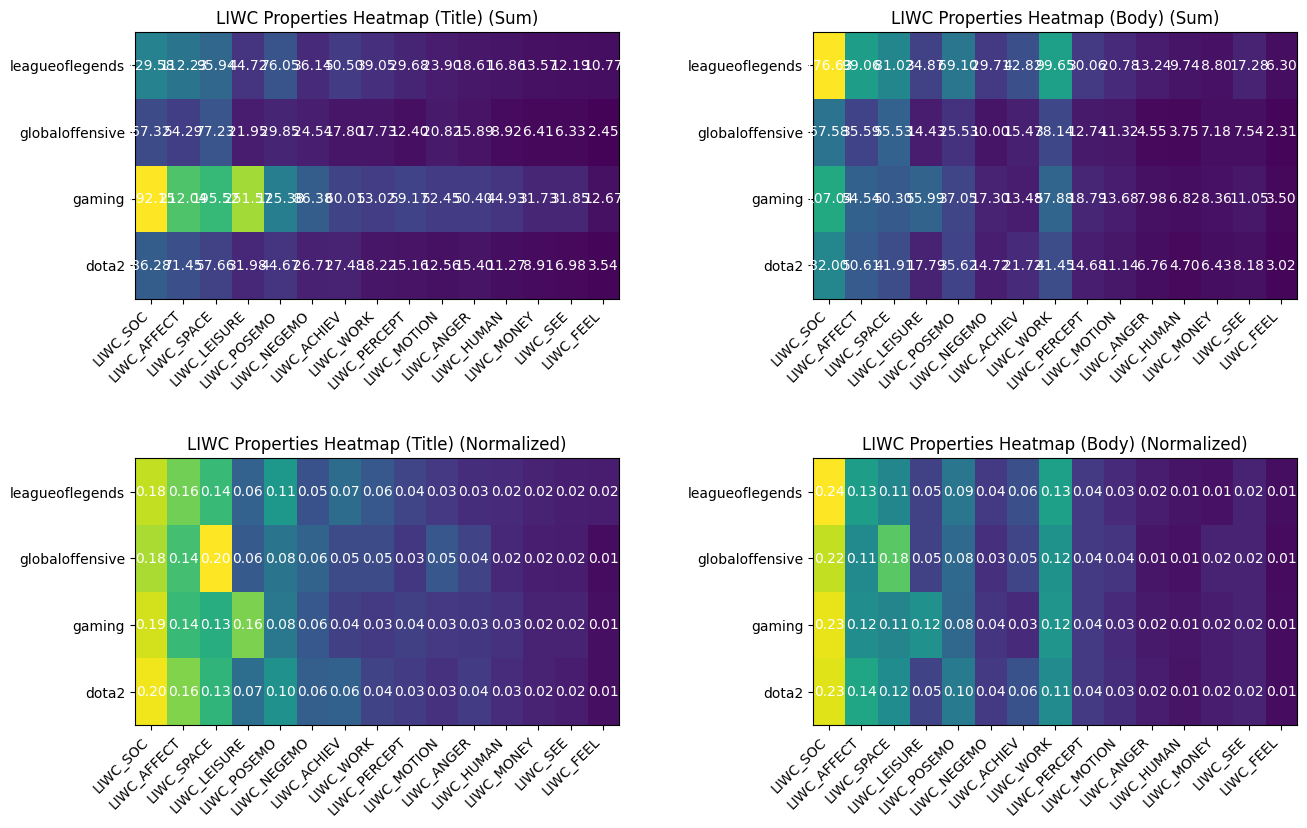

In [33]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list
from week1_Yuri import get_dataframe_features
print("Length of selected properties:", len(selected_PROPERTIES))
subreddits_list = games
df_features = get_dataframe_features(
    df_title, df_body, selected_PROPERTIES.keys(), subreddits_list
)
display(df_features.sort_values(
    by=['Sum_Body', 'Sum_Title',], ascending=False
).head(10))

# VADER sentiment
# properties_list = [ "VADER_POS", "VADER_NEG", "VADER_COMP",]

# LIWC properties
properties_list = df_features.sort_values(
    by=['Sum_Title', 'Sum_Body', ], ascending=False
).head(15)["Feature"].tolist()
print(properties_list)
fig, ax = plt.subplots(2, 2, figsize = (15, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plot_liwc_heatmaps_for_features_list(
    ax[0, 0], df_title, games, properties_list, title='LIWC Properties Heatmap (Title)')

plot_liwc_heatmaps_for_features_list(
    ax[0, 1], df_body, games, properties_list, title='LIWC Properties Heatmap (Body)')

plot_liwc_heatmaps_for_features_list(
    ax[1, 0], df_title, games, properties_list, title='LIWC Properties Heatmap (Title)', normalize=True)

plot_liwc_heatmaps_for_features_list(
    ax[1, 1], df_body, games, properties_list, title='LIWC Properties Heatmap (Body)', normalize=True)

<Axes: title={'center': 'CS:GO (Normalized)'}>

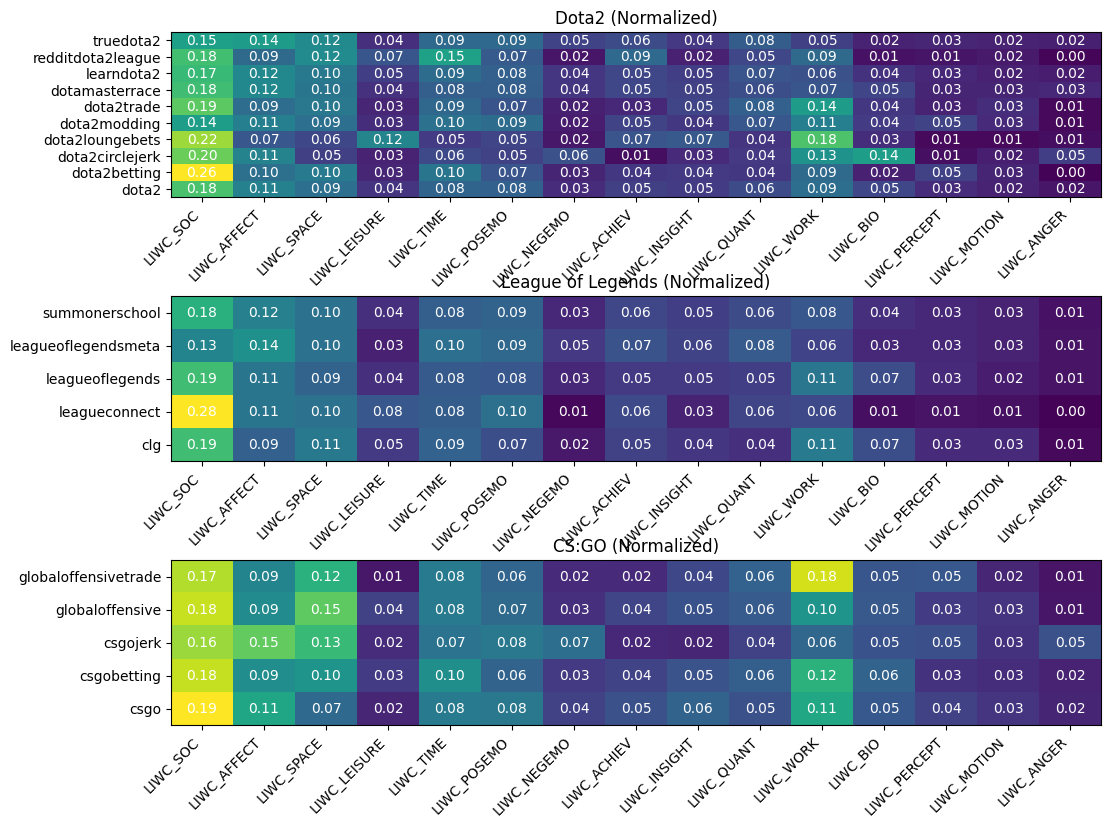

In [28]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list

fig, ax = plt.subplots(3, 1, figsize = (12, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
# properties_list = df_features_liwc.sort_values(by=['Sum_Title', 'Sum_Body'], ascending=False).head(10)["Feature"].tolist()
plot_liwc_heatmaps_for_features_list(
    ax[0], df_body, dota2_subreddits, properties_list, title='Dota2',normalize=True)
plot_liwc_heatmaps_for_features_list(
    ax[1], df_body, lol_subreddits, properties_list, title='League of Legends', normalize=True)
# plot_liwc_heatmaps_for_features_list(
#     ax[1][0], df_body, starcraft2_subreddits, properties_list, title='Starcraft2', normalize=True)
plot_liwc_heatmaps_for_features_list(
    ax[2], df_body, globaloffensive_subreddits, properties_list, title='CS:GO'  , normalize=True)

### Spikes and trends of selected features over time for a given subreddits

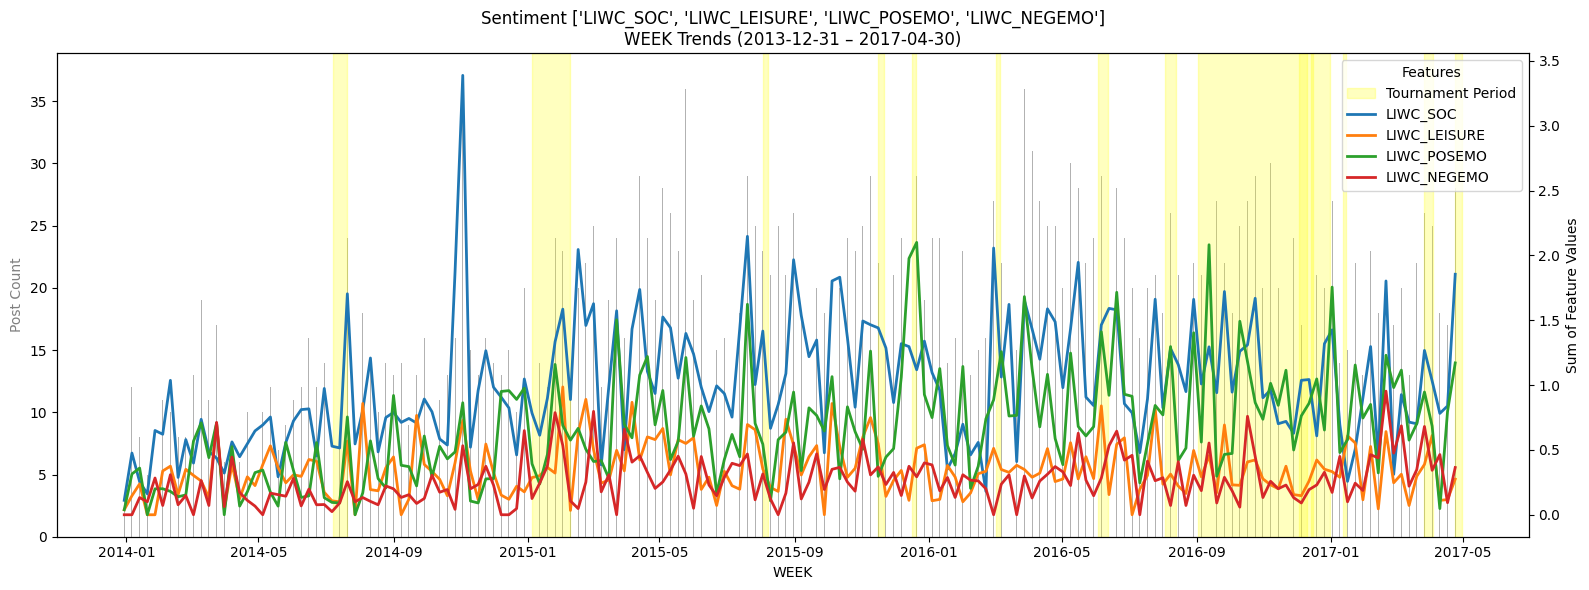

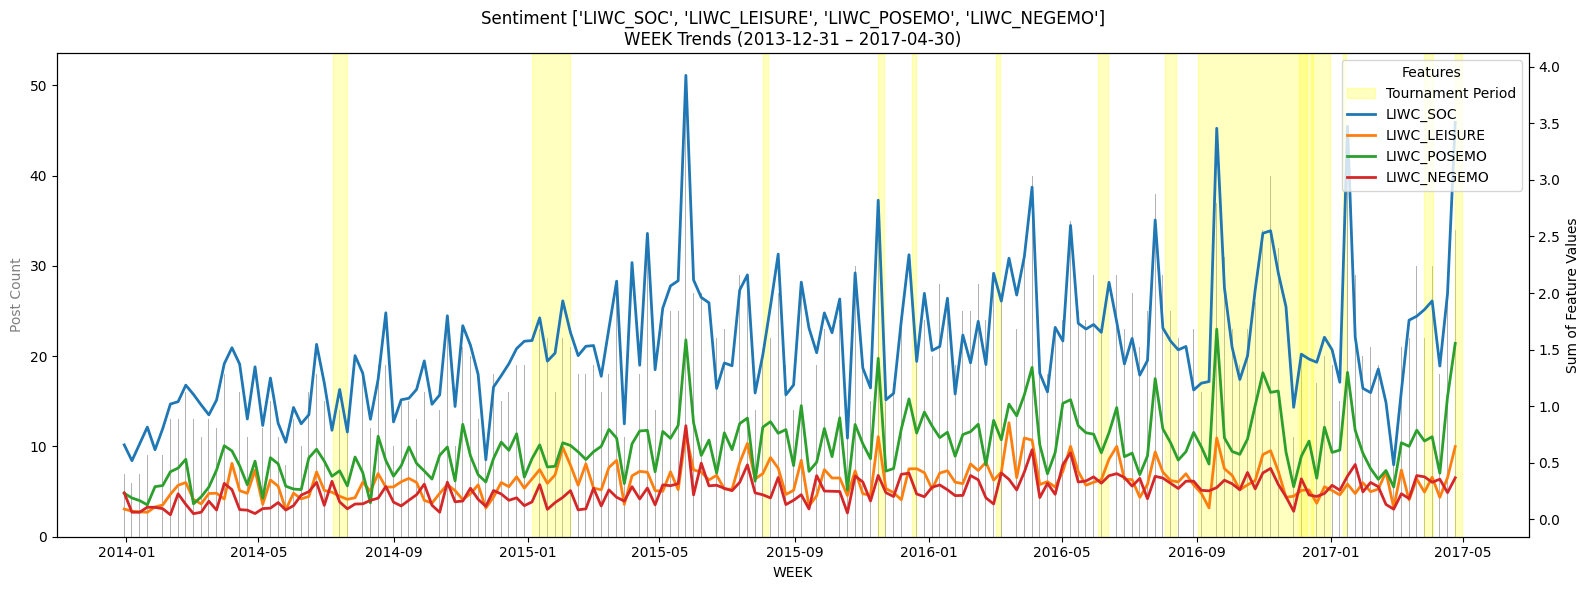

In [49]:
from week1_Yuri import plot_subreddits_features_trend

subreddits_list = lol_subreddits
features_list = ["LIWC_SOC", "LIWC_LEISURE", "LIWC_POSEMO", "LIWC_NEGEMO"]
period = "W"

plot_subreddits_features_trend(
    df_title,
    subreddits_list,
    "2013-12-31",
    "2017-04-30",
    features_list,
    period,
    highlight_periods=formatted_dates    # ← add highlight ranges
)

plot_subreddits_features_trend(
    df_body,
    subreddits_list,
    "2013-12-31",
    "2017-04-30",
    features_list,
    period,
    highlight_periods=formatted_dates
)


Title
3338


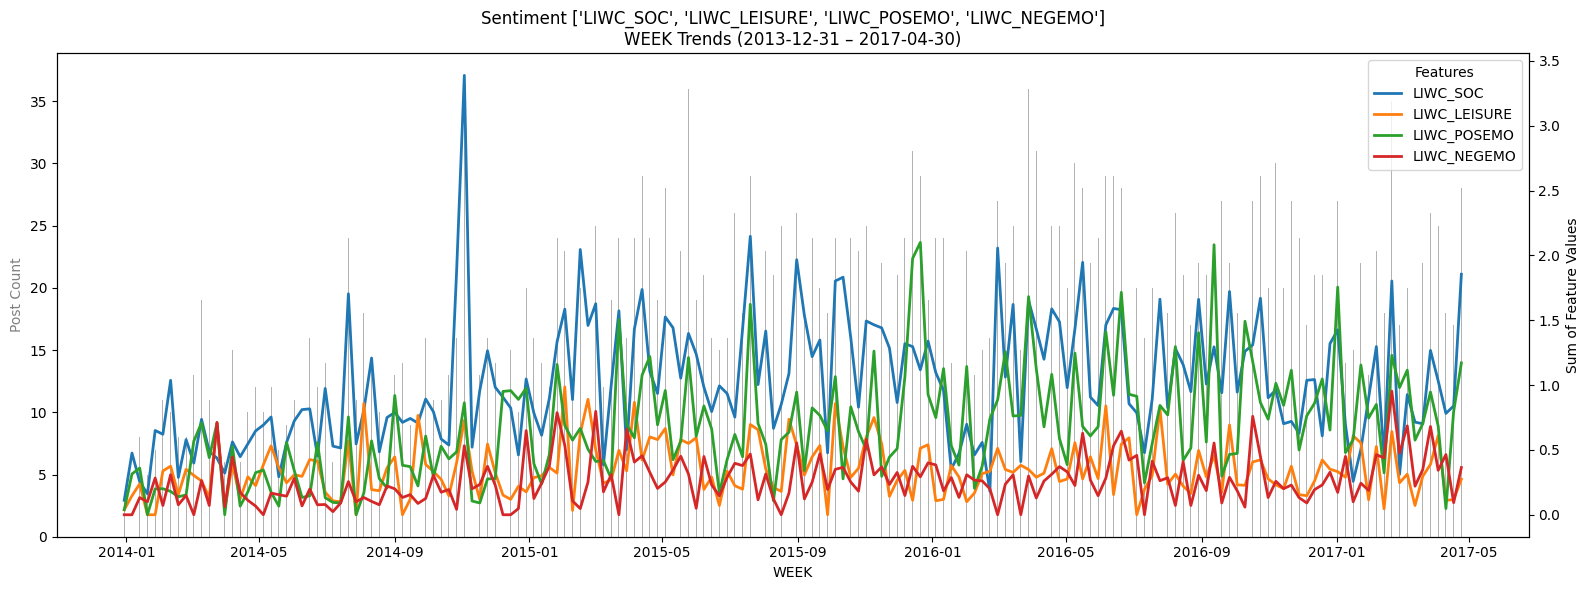

Body
3609


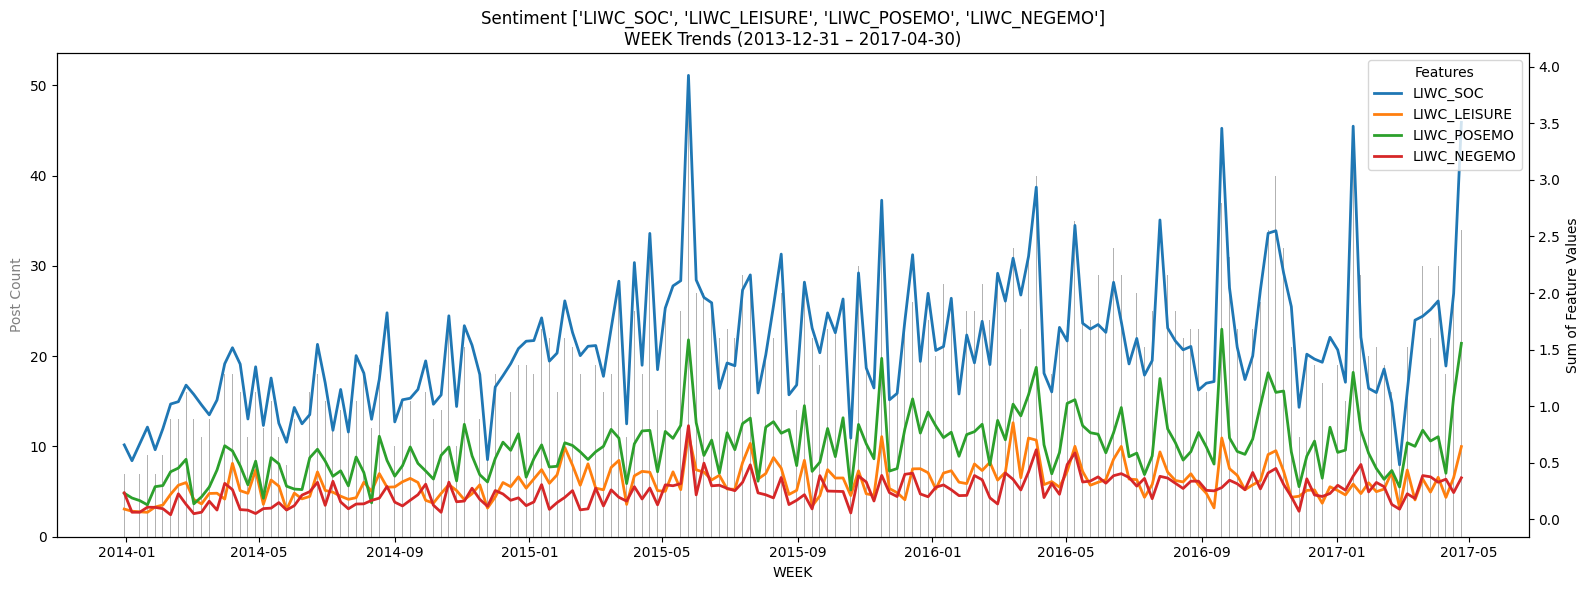

In [23]:
from week1_Yuri import plot_subreddits_features_trend 
subreddits_list = lol_subreddits
start_time = "2013-12-31"
end_time = "2017-04-30"
features_list = [
    "LIWC_SOC",
    "LIWC_LEISURE",
    "LIWC_POSEMO",
    "LIWC_NEGEMO",
]
period = "W"  # "D" for daily, "W" for weekly, "M" for monthly, "Q" for quarterly, "Y" for yearly
print("Title")
plot_subreddits_features_trend(df_title, subreddits_list, start_time, end_time, features_list, period)
print("Body")
plot_subreddits_features_trend(df_body, subreddits_list, start_time, end_time, features_list, period)